In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
cfe = pd.read_pickle('CFE.pkl').values
cfe = xr.DataArray(cfe,dims=['eddy','day'],coords={'eddy':np.arange(cfe.shape[0]),'day':np.arange(cfe.shape[1])})
cste = pd.read_pickle('CSTE.pkl').values
cste = xr.DataArray(cste,dims=['eddy','day'],coords={'eddy':np.arange(cste.shape[0]),'day':np.arange(cste.shape[1])})

In [3]:
avg = lambda D,std: D.mean('eddy')+std*D.std('eddy')
gwr = lambda D,std: (avg(D,std).differentiate('day')/avg(D,std))
std = lambda D: np.abs(np.vstack([gwr(D,-1)-gwr(D,0),gwr(D,1)-gwr(D,0)])).max(0)

func = lambda x,a,b,c: a*np.exp(-x/b)

In [ ]:
popt,_=curve_fit(func, cste.day, gwr(cste,0))

In [72]:
def get_fit(D):
    fit = []
    for gwri in (D.differentiate('day')/D).values:
        popt,_=curve_fit(func, np.arange(len(gwri))[~np.isnan(gwri)], gwri[~np.isnan(gwri)])
        fit.append(func(np.arange(len(gwri)),*popt))
    fit = np.vstack(fit)*xr.ones_like(cfe)
    fit = fit.where((fit.min('day')>=0)&(fit.max('day')<=0.4),drop=True)

    return fit

/home/is96d/.local/lib/python3.6/site-packages/scipy/optimize/minpack.py:787: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


[(-0.01, 0.25), (0.0, 30.0)]

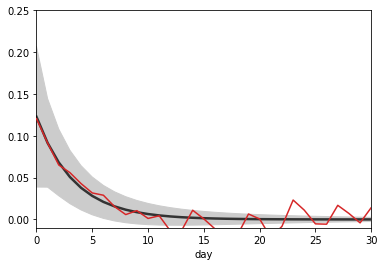

In [71]:
fig,ax = plt.subplots()

popt,_=curve_fit(func, cfe.day, (cfe.differentiate('day')/cfe).mean('eddy'))
ax.plot(cfe.day,func(cfe.day,*popt),lw=2.5,color='0.2',zorder=1)
ax.fill_between(fit.day,func(cfe.day,*popt)-fit.std('eddy'),func(cfe.day,*popt)+fit.std('eddy'),color='0.8',zorder=0)
(cfe.differentiate('day')/cfe).mean('eddy').plot(color='tab:red',zorder=5)
ax.set(xlim=[0,30],ylim=[-0.01,0.25])

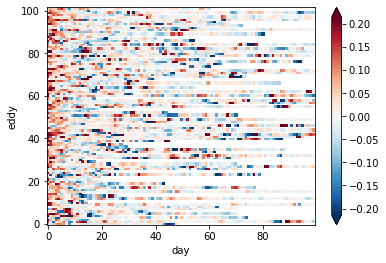

In [15]:
(cfe.differentiate('day')/cfe).plot(x='day',robust=True)

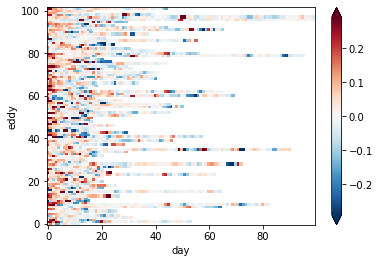

In [12]:
(cste.differentiate('day')/cfe).plot(x='day',robust=True)

/home/is96d/.local/lib/python3.6/site-packages/scipy/optimize/minpack.py:787: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)
/home/is96d/.local/lib/python3.6/site-packages/scipy/optimize/minpack.py:787: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


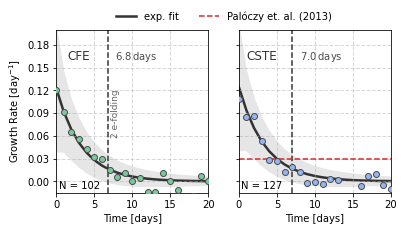

In [107]:
kw = {
    'xlim':[0,20],
    'ylim':[-0.015,0.2]
}

ne=2

fig,ax = plt.subplots(1,2,figsize=(6,3))

popt,_=curve_fit(func, cfe.day, (cfe.differentiate('day')/cfe).mean('eddy'))
ax[0].plot(cfe.day,func(cfe.day,*popt),lw=2.5,color='0.2',zorder=1)
fitstd = fit.std('eddy')
ax[0].fill_between(fit.day,func(cfe.day,*popt)-fitstd,func(cfe.day,*popt)+fitstd,color='0.9',zorder=0)
(cfe.differentiate('day')/cfe).mean('eddy').plot(ax=ax[0],marker='o',color='#78ca9cff',lw=0,markeredgecolor='0.3',zorder=5)
ax[0].axvline(ne*popt[1],color='0.2',linestyle='--')
ax[0].text(ne*popt[1]+1,0.16,'{:.1f}$\,$days'.format(ne*popt[1]),color='0.3')
ax[0].text(3,-0.01,'N = {}'.format(cfe.shape[0]),ha='center')



popt,_=curve_fit(func, cste.day, (cste.differentiate('day')/cfe).mean('eddy'))
ax[1].plot(cste.day,func(cste.day,*popt),lw=2.5,color='0.2',zorder=1,label='exp. fit')
ax[1].fill_between(fit.day,func(cste.day,*popt)-fit.std('eddy'),func(cste.day,*popt)+fit.std('eddy'),color='0.9',zorder=0)
(cste.differentiate('day')/cste).mean('eddy').plot(ax=ax[1],marker='o',color='#93b5f3ff',lw=0,markeredgecolor='0.3',zorder=5)
ax[1].axvline(ne*popt[1],color='0.2',linestyle='--')#,label='e-folding')
ax[1].text(ne*popt[1]+1,0.16,'{:.1f}$\,$days'.format(ne*popt[1]),color='0.3')
# ax[1].scatter([],[],color='k',label='Palóczy et. al. (2013)')
# ax[1].plot(5,0.03,markersize=8,color='0.1',marker='o',markeredgecolor='w',zorder=1e5)
ax[1].axhline(0.03,color='tab:red',linestyle='--',label='Palóczy et. al. (2013)')
ax[1].text(3,-0.01,'N = {}'.format(cste.shape[0]),ha='center')


_ = [a.grid(True,linewidth=1,linestyle='--',alpha=0.5) for a in ax]
_ = [a.set(xlabel='Time [days]',yticks=np.arange(0,0.23,0.03),**kw) for a in ax]


ax[0].text(7.8,0.06,'2 e-folding',rotation=90,ha='center',color='0.4',fontsize=9)
ax[0].text(3,0.16,'CFE',ha='center',color='0.2',fontsize=12)
ax[0].set(ylabel='Growth Rate [day$^{-1}$]')
ax[1].text(3,0.16,'CSTE',ha='center',color='0.2',fontsize=12)
ax[1].set(yticklabels=[])

ax[1].legend(ncol=3,loc='upper center', bbox_to_anchor=(-0.1, 1.17),frameon=False)

fig.savefig('img/cfe_cste.png',dpi=300,bbox_inches='tight')